# Обзор таблицы

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [4]:
df.shape

(100000, 11)

In [5]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


# Анализ пропусков

Ниже мы видим, что все 11 столбцов имеют 100000 строк Non-Null, что означает, что пропусков в таблице нет

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Здесь подтверждение того, что пропусков нет

In [7]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

# Переназываю стобцы

In [8]:
df = df.rename(columns={'Stress_Level': 'Stress'})
df = df.rename(columns={'Sleep_Duration': 'Sleep'})
df = df.rename(columns={'Physical_Activity': 'Activity'})
df = df.rename(columns={'Social_Media_Hours': 'Media'})
df = df.rename(columns={'Study_Hours': 'Study'})

# Графики

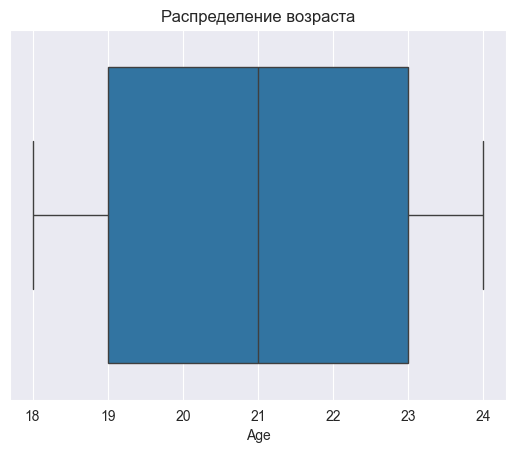

In [9]:
sns.boxplot(x=df['Age'])
plt.title("Распределение возраста")
plt.show()

Нулевое количество часов учебы выглялит странно для студента, скорее всего здесь 0 обозначает отсутствие данных

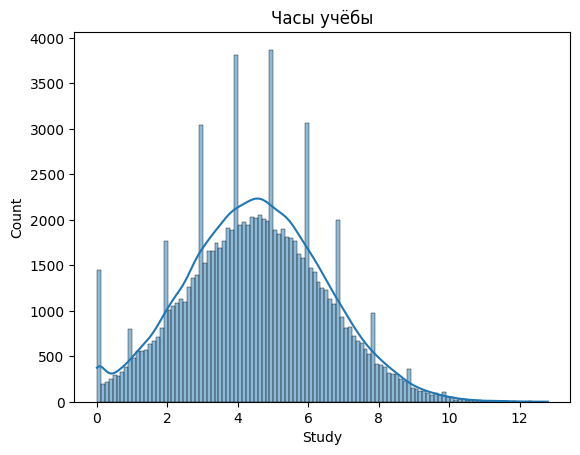

In [10]:
sns.histplot(df['Study'], kde=True)
plt.title("Часы учёбы")
plt.show()

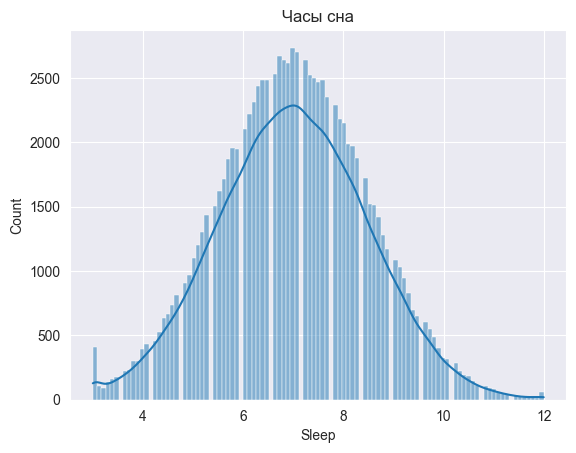

In [10]:
sns.histplot(df['Sleep'], kde=True)
plt.title("Часы сна")
plt.show()

Нулевое кол-во часов, проведенных в соц сетях (причем в нуле можно наблюдать резкий рост графика) довольно странно, возмодно это означает отсутствие данных.

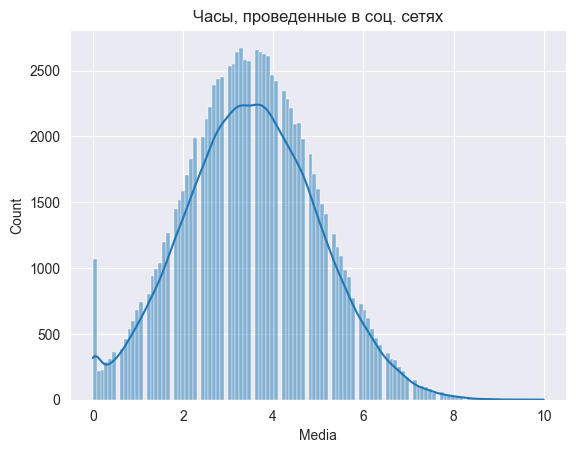

In [11]:
sns.histplot(df['Media'], kde=True)
plt.title("Часы, проведенные в соц. сетях")
plt.show()

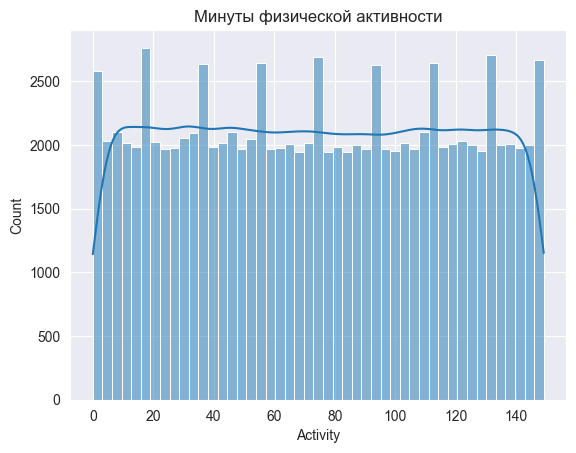

In [12]:
sns.histplot(df['Activity'], kde=True)
plt.title("Минуты физической активности")
plt.show()

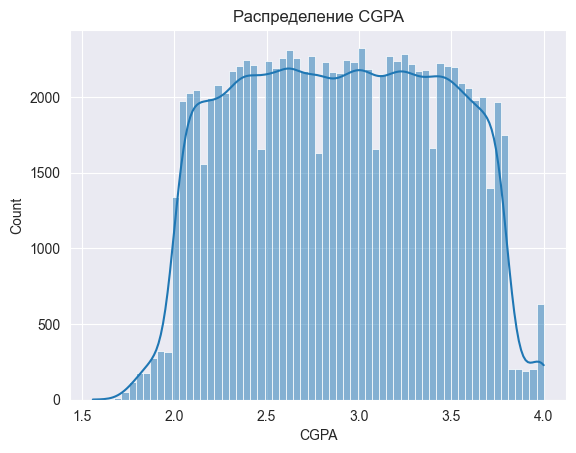

In [13]:
sns.histplot(df['CGPA'], kde=True)
plt.title("Распределение CGPA")
plt.show()

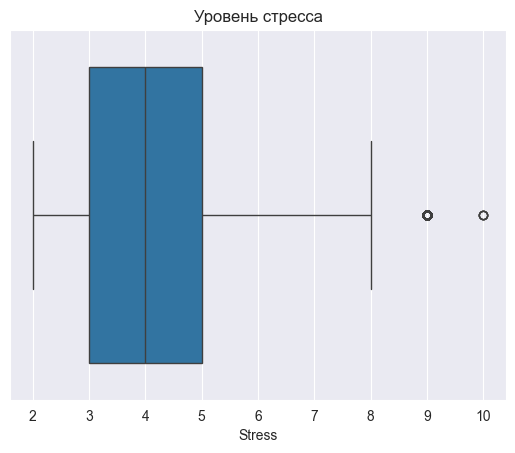

In [14]:
sns.boxplot(x=df['Stress'])
plt.title("Уровень стресса")
plt.show()

Как можно заметить по графику корреляции числовых признаков, корреляции нигде не наблюдается, что может мешать обучению модели

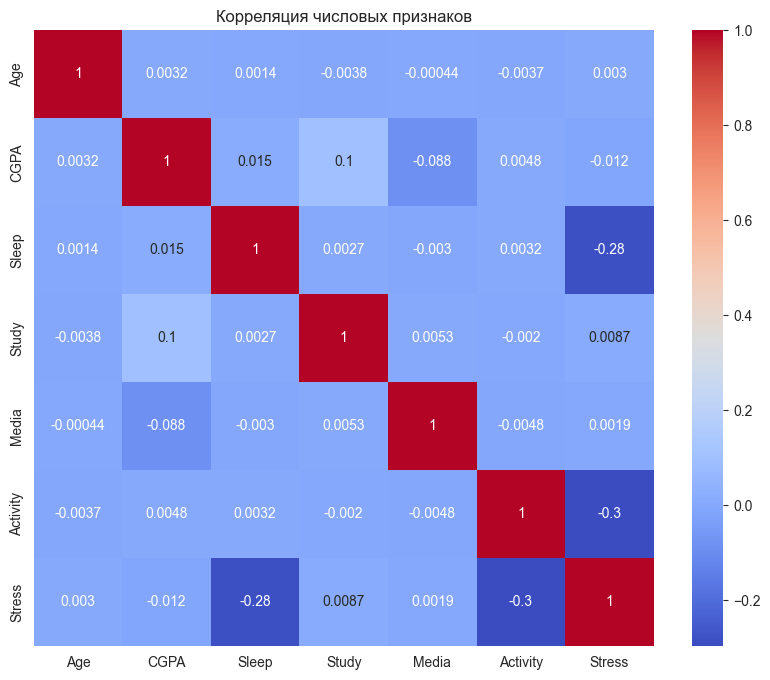

In [15]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number']).drop("Student_ID", axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()

# Удаление столбцов

Я приняла решение удалить столбец Age, так как проверила,что возраст всех опрашиваемых от 18 до 24. Выбросов нет, возраст находится в узком диапозонее значений и потенциально не может влиять на стиль жизни, уровень стресса и наличие депрессии.

In [16]:
df = df.drop('Age', axis=1)

Удаляю столбец с id студента, тк он не несет никакой информации о студенте, не связан с другими признаками, не помогает модели и даже может внести шум.

In [17]:
df = df.drop('Student_ID', axis=1)

# Поиск выбросов и дисбаланса классов

Отношение True/False ~ 1:9 => дисбаланс классов, плохо для обучения модели, модель может научиться отвечать, что депрессии нет

In [18]:
print(df['Depression'].value_counts())

Depression
False    89938
True     10062
Name: count, dtype: int64


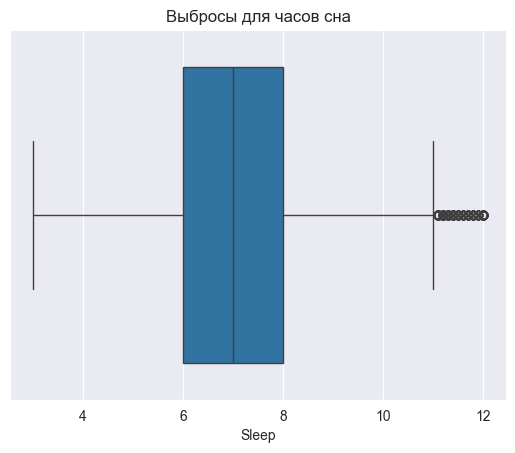

In [19]:
sns.boxplot(x=df['Sleep'])
plt.title("Выбросы для часов сна")
plt.show()

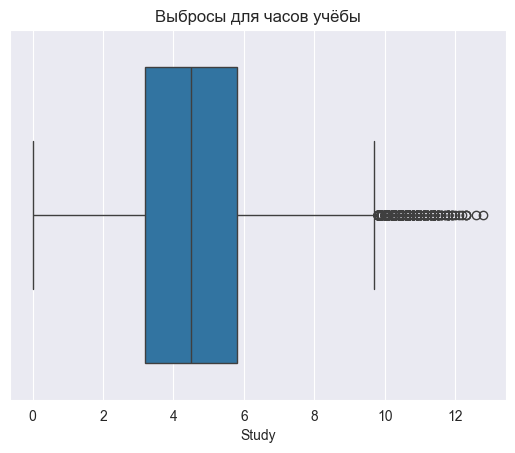

In [21]:
sns.boxplot(x=df['Study'])
plt.title("Выбросы для часов учёбы")
plt.show()

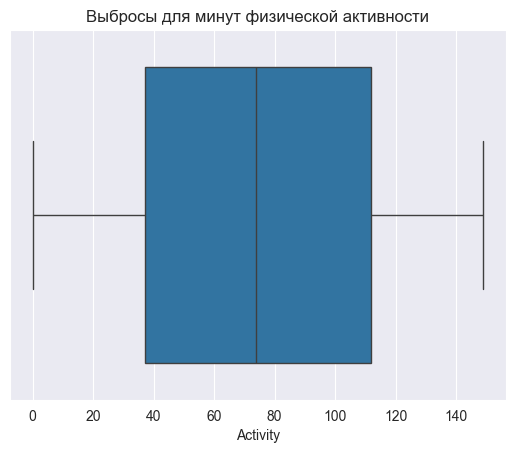

In [22]:
sns.boxplot(x=df['Activity'])
plt.title("Выбросы для минут физической активности")
plt.show()

# Обработка нулей

Заменяем выше описанные нули в Study и Media на медиану (она устойчива к выбросам, не смещает распределение, подходит для синтетических данных)

In [24]:
df['Study'] = df['Study'].replace(0, df['Study'].median())
df['Media'] = df['Media'].replace(0, df['Media'].median())

# Удаление дубликатов

In [25]:
df = df.drop_duplicates()
df.shape

(100000, 9)

получается, дубликатов нет

# One-Hot Encoding

Превращение текстовых данных в числовые столбцы (для Gender и Department) тк модель машинного обучения не умеет работать со строками

In [26]:
df = pd.get_dummies(df, columns=['Gender', 'Department'], drop_first=True)

In [27]:
df.columns

Index(['CGPA', 'Sleep', 'Study', 'Media', 'Activity', 'Stress', 'Depression',
       'Gender_Male', 'Department_Business', 'Department_Engineering',
       'Department_Medical', 'Department_Science'],
      dtype='str')

In [28]:
df.shape

(100000, 12)

# Масштабирование

In [29]:
X = df.drop(columns=['CGPA', 'Depression'])

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['Study', 'Sleep']]
y = df['CGPA']

# Разделение
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42, shuffle=True
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение модели

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_val_pred = model.predict(X_val_scaled)

# Оценка качества модели

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def evaluate_model(y_true, y_pred, dataset="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100


    return f'Датасет: {dataset}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, MAPE: {mape}\n'

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
val_metrics = evaluate_model(y_val, y_val_pred, "Val")
print(train_metrics, test_metrics, val_metrics)

Датасет: Train, MAE: 0.45549411683558844, RMSE: 0.52906350146938, R2: 0.011386530947438689, MAPE: 16.594224365724493
 Датасет: Test, MAE: 0.4595816695063733, RMSE: 0.5333497939425347, R2: 0.007505123152157789, MAPE: 16.71131992326523
 Датасет: Val, MAE: 0.45267228420973527, RMSE: 0.5278042011580669, R2: 0.007962993016581987, MAPE: 16.44773652920971



В рамках задания была обучена модель линейной регрессии для прогнозирования успеваемости студента только на основе его режима занятий и сна, как указано в условии. Для корректной оценки качества данные были разделены на три выборки: обучающую (80%), валидационную (10%) и тестовую (10%), при этом масштабирование признаков выполнялось исключительно по обучающей выборке, что исключает утечку данных.

Результаты на всех трёх выборках оказались практически одинаковыми:
MAE ~ 0.45, RMSE ~ 0.53, MAPE ~ 16–17%, R² ~ 0.01.
Близость метрик Train, Val и Test показывает, что модель не переобучена и ведёт себя стабильно.

Однако значение R2 около 0.01 говорит о том, что модель объясняет лишь около 1% вариации целевой переменной. Это означает, что CGPA практически не зависит от количества часов сна и занятий, и линейная регрессия на этих признаках не способна построить качественный прогноз.

Таким образом, модель линейной регрессии получилась стабильной, но слабой по качеству - и это отражает ограниченность исходных признаков, а не ошибки в методологии.

# Feature Engineering

Гипотеза 1: нелинейность - квадрат часов учёбы

Гипотеза 2: отклонение сна от нормы.
Слишком мало и слишком много - оба случая плохи для успеваемости

In [33]:
df['Study_sq'] = df['Study'] ** 2

df['Sleep_deviation'] = (df['Sleep'] - 7.5).abs()

print(df[['Study_sq','Sleep_deviation','CGPA']].corr()['CGPA'])

Study_sq           0.120939
Sleep_deviation   -0.018736
CGPA               1.000000
Name: CGPA, dtype: float64


In [34]:
X = df[['Study', 'Study_sq', 'Sleep', 'Sleep_deviation']]
y = df['CGPA']

# Разделение
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42, shuffle=True
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение модели после Feature Engineering

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_val_pred = model.predict(X_val_scaled)

# Оценка ккачества модели после Feature Engineering

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np


def evaluate_model(y_true, y_pred, dataset="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return f'Датасет: {dataset}, MAE: {mae}, RMSE: {rmse}, R2: {r2}, MAPE: {mape}\n'


train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
val_metrics = evaluate_model(y_val, y_val_pred, "Val")
print(train_metrics, test_metrics, val_metrics)

Датасет: Train, MAE: 0.45435937329048, RMSE: 0.5272364180015255, R2: 0.018202954273950356, MAPE: 16.549366823837463
 Датасет: Test, MAE: 0.45817260959925316, RMSE: 0.5312003966301219, R2: 0.015488504112063484, MAPE: 16.654580108862795
 Датасет: Val, MAE: 0.45067823952498115, RMSE: 0.5249356425217906, R2: 0.018716917436823577, MAPE: 16.369088488090867



Feature engineering удвоил R2, что подтверждает нелинейный характер зависимости. Тем не менее абсолютное значение остаётся низким - данные объективно не позволяют точно предсказать CGPA по режиму дня.